### Import all required modules

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import json as js
import os
import pandas as pd
import pyfftw  # FFTW used in Matlab.
from scipy.optimize import curve_fit
from scipy.special import erf
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

# Constants
c = 299792458  # speed of light in m/s
q = 1.60217646E-19                         # electronic charge
permittivity = 8.854187817620E-12          # permittivity of free space

# Bandwidth range
bandwidth = ()
bandwidth_xlim = (-0.01, 10)
bandwidth_ylim = (2, 1e5)

fontsize = 25
tick_fontsize = 15
figure_size_3 = (10, 13)
figure_size_2 = (18, 6.5)
figure_size_1 = (15, 6.5)


### Sample attributes
When the file type is json or hfd5, sample and experimental attributes may be saved within the file for convenience. This function helps to extract those attributes. Typically, attributes will be saved as strings.

Available attributes: <br>
**Sample**:
- Sample name
- Sample type (thin films, nanowires, etc)
- Sample thickness/diameter
- Sample reference
- Sample description
- Passivation layer
- Temperature
- Sample fabriation technique

**Experimental**:
- Pump fluence
- Vacuum/purged conditions
- Emitter & detector
- Pump wavelength


### Reminder of sampling scheme
Sampling scheme is dependent on the frequency at which we chop the THz generation pulse, and the pump pulse. Current default is 2500 Hz and 1250 Hz respectively, but one must always adjust the code accordingly, or better yet, encode it within the experimentation program so ABCD signal would always adhere to the following scheme:

## Pulses schematic
A: E_on + pump + gate pulse <br>
B: Pump + gate pulse        <br>
C: E_off + gate pulse       <br>
D: Gate pulse (balance)

Therefore, to get the relevant information: <br>
**Dark THz signal**:<br>
&nbsp;&nbsp;&nbsp;&nbsp;- *E_off* = (C - D)<br>
**Pump THz signal**:<br>
&nbsp;&nbsp;&nbsp;&nbsp;- *E_on* = (A - B)<br>
**Change in sample properties between excited and unexcited states**:<br>
&nbsp;&nbsp;&nbsp;&nbsp;- *DT* = (A - B) - (C - D)<br>
**Sample THz emission**: <br>
&nbsp;&nbsp;&nbsp;&nbsp;- *sample_emission* = (B - D)



In [2]:
def generate_cleaned_up_dataframe(filepath,
                                  limits: list = []):
    """
    Automatically reads data files with extension .txt and .hfd5.
    Cleans up the dataframe by sorting the delay.
    Also adds columns for E_on, E_off, Delta_E and their respective FFTs.
    Also adds a column for the frequencies at which the FFTs are taken.
    """
    # TODO: Add file type handling (e.g., .txt, .hdf5)
    if filepath.endswith('.txt'):
        if limits != []:
            dataframe = pd.read_csv(filepath, sep="	", header=0, skiprows=limits[0], nrows=limits[1])
        else:
            dataframe = pd.read_csv(filepath, sep="	", header=0)
    dataframe = dataframe.sort_values(by='Delay (mm)')
    dataframe = dataframe.reset_index(drop=True)

    # convert position of delay stage to time delay (in seconds)
    dataframe.insert(1, 'Delay (s)', dataframe['Delay (mm)']*((2E-3)/c))
    
    # Get E on, E off, Delta E and their respective FFTs
    dataframe.insert(2, 'E_off', dataframe['C'] - dataframe['D'])
    dataframe.insert(3, 'fft_E_off', pyfftw.builders.fft(dataframe['E_off'])())
    dataframe.insert(4, 'fft_E_off_dB', 20 * np.log10(dataframe['fft_E_off'].abs()))
    dataframe.insert(5, 'E_on', dataframe['A'] - dataframe['B'])
    dataframe.insert(6, 'fft_E_on', pyfftw.builders.fft(dataframe['E_on'])())
    dataframe.insert(7, 'fft_E_on_dB', 20 * np.log10(dataframe['fft_E_on'].abs()))
    dataframe.insert(8, 'Delta_E', dataframe['E_on'] - dataframe['E_off'])
    dataframe.insert(9, 'fft_Delta_E', pyfftw.builders.fft(dataframe['Delta_E'])())
    dataframe.insert(10, 'fft_Delta_E_dB', 20 * np.log10(dataframe['fft_Delta_E'].abs()))

    # calculate the frequencies, f, at which the fft is taken
    num_data_points = len(dataframe)
    double_bandwidth = num_data_points/(dataframe['Delay (s)'].iloc[-1] -
                                        dataframe['Delay (s)'].iloc[0])
    dataframe.insert(2, 'Frequencies (Hz)', np.linspace(0, double_bandwidth, num_data_points))

    return dataframe

# Example usage
# generate_cleaned_up_dataframe("D:/Aldric/Data/250822/1_vacuum_pumped_Dark THz.txt")

# Useful plotting functions

In [3]:
def annotate_subplots(subplot_list, fontsize=tick_fontsize,
                      annotation_fontsize=fontsize):
    labels = ('a)', 'b)', 'c)', 'd)', 'e)', 'f)', 'g)', 'h)', 'i)', 'j)', 'k)',
              'l)', 'm)', 'n)', 'o)', 'p)', 'q)', 'r)', 's)', 't', 'u)', 'v',
              'w)', 'x)', 'y)', 'z)')
    num = 0
    for subplot in subplot_list:
        # Use Axes.annotate to put the label
        # - at the top left corner (axes fraction (0, 1)),
        # - offset half-a-fontsize right and half-a-fontsize down
        #   (offset fontsize (+0.5, -0.5)),
        # i.e. just inside the axes.
        subplot.annotate(
            labels[num],
            xy=(0, 1), xycoords='axes fraction',
            xytext=(+0.5, -0.5), textcoords='offset fontsize',
            fontsize=annotation_fontsize, verticalalignment='top')
        subplot.tick_params(axis='both', which='major', labelsize=fontsize)
        num = num + 1


def xy_line_markers(subplot,
                    x_value,
                    y_value,
                    x_min=0,
                    y_min=0,
                    line_style='dashed',
                    line_colour='r',
                    plot_h_line=True,
                    plot_v_line=True):
    if plot_h_line:
        if x_value > x_min:
            subplot.hlines(y=y_value, xmin=x_min, xmax=x_value,
                        linestyles=line_style, color=line_colour)
        elif x_value < x_min:
            subplot.hlines(y=y_value, xmin=x_value, xmax=x_min,
                        linestyles=line_style, color=line_colour)
    if plot_v_line:
        if y_value > y_min:
            subplot.vlines(x=x_value, ymin=y_min, ymax=y_value,
                           linestyles=line_style, color=line_colour)
        elif y_value < y_min:
            subplot.vlines(x=x_value, ymin=y_value, ymax=y_min,
                           linestyles=line_style, color=line_colour)


def create_folder(name):
    if not os.path.exists(name):
        os.makedirs(name)
        print(f"{name} created!")
    else:
        print(f"{name} exists!")


def fig_save(filename):
    increments = 1
    if os.path.exists(f'{filename}.png'):
        print(filename)
        while os.path.exists(f'{filename} ({increments}).png'):
            increments += 1
        plt.savefig(f'{filename} ({increments}).png')
        print('WARNING: Figures were duplicated!')
    else:
        plt.savefig(f'{filename}.png')

Legacy function primarily allows for non-dB spectrum to be plotted. <br>
Best not to use it, as quantification of bandwidth and dynamic range are much easier using dB units.

In [4]:
def extract_bandwidth(dataframe):
    max_fft_E_off = dataframe[(dataframe['Frequencies (Hz)'] * 1e-12 < 20)]['fft_E_off'].abs().max()
    max_fft_E_off_index = dataframe.index[(dataframe['fft_E_off'].abs() == max_fft_E_off)][0]
    print('fft_E max at = ', dataframe['Frequencies (Hz)'][max_fft_E_off_index] * 1e-12)
    print(max_fft_E_off_index)
    bandwidth_lower_cond = ((dataframe['fft_E_off'].abs() < max_fft_E_off/10) &
                            (dataframe['Frequencies (Hz)'] * 1e-12 >
                             bandwidth_xlim[0]) &
                            (dataframe['Frequencies (Hz)'] * 1e-12 <
                             dataframe['Frequencies (Hz)']
                             [max_fft_E_off_index] * 1e-12))
    bandwidth_upper_cond = ((dataframe['fft_E_off'].abs() >= max_fft_E_off/10) &
                            (dataframe['Frequencies (Hz)'] * 1e-12 <
                             bandwidth_xlim[1]) &
                            (dataframe['Frequencies (Hz)'] * 1e-12 >
                             dataframe['Frequencies (Hz)']
                             [max_fft_E_off_index] * 1e-12))
    if any(dataframe.index[bandwidth_lower_cond]):
        BW_lower_index = dataframe.index[bandwidth_lower_cond][0]+1
    else:
        BW_lower_index = 0
    BW_index = list(dataframe.index[bandwidth_upper_cond])
    BW_upper_index = [BW_index[i] for i in range(len(BW_index))
                        if ((BW_index[i] - BW_index[i-1]) == 1)][-1]
    BW_lower = round(dataframe['Frequencies (Hz)'][BW_lower_index] * 1e-12, 3)
    BW_upper = round(dataframe['Frequencies (Hz)'][BW_upper_index] * 1e-12, 3)
    print('Bandwidth lower limit = ', BW_lower, ' THz')
    print('Bandwidth upper limit = ', BW_upper, ' THz')
    bandwidth = round((dataframe['Frequencies (Hz)'][BW_upper_index] -
                        dataframe['Frequencies (Hz)'][BW_lower_index]) * 1e-12, 3)
    print('Bandwidth = ', round(bandwidth, 3), ' THz')

    return BW_lower_index, max_fft_E_off_index, BW_upper_index, bandwidth

def plot_dark_spectrum(dark_axs,
                       dataframe,
                       label = None,
                       color = 'black',
                       plot_noise = True,
                       **kwargs):
    """
    Plots the time and frequency domain of dark THz from the dataframe.
    Can pass upper and lower bandwidth indexes as kwargs to highlight them.
    Can also pass dB=True to change y-axis to dB scale.
    Can also pass if SNR data are to be plotted instead.
    """
    dark_axs[0].plot(dataframe['Delay (s)'] * 1e12, dataframe['E_off'],
                         color=color, label=label)
    dark_axs[1].plot(dataframe['Frequencies (Hz)'] * 1e-12,
                    dataframe['fft_E_off_dB'] - dataframe['fft_E_off_dB'].max(),
                    color=color, label=label)
    
    if plot_noise == True:
        noise_level = 20*np.log10(abs(pyfftw.builders.fft(dataframe['Emitter noise'])()))
        noise_level = noise_level - noise_level.max()
        dark_axs[1].plot(dataframe['Frequencies (Hz)'] * 1e-12,
                    noise_level,
                    color=color, alpha=0.3, linestyle='--', label=f'{label} noise')

    if (kwargs.get('BW_lower_index') is not None and
        kwargs.get('BW_upper_index') is not None):
        BW_lower_index = kwargs.get('BW_lower_index')
        BW_upper_index = kwargs.get('BW_upper_index')
        xy_line_markers(dark_axs[1],
                        dataframe['Frequencies (Hz)'][BW_lower_index] * 1e-12,
                        -20, y_min=bandwidth_ylim[0],
                        plot_h_line=False, line_colour=color)
        xy_line_markers(dark_axs[1],
                        dataframe['Frequencies (Hz)'][BW_upper_index] * 1e-12,
                        -20, y_min=bandwidth_ylim[0], plot_h_line=False, line_colour=color)
    dark_axs[1].set_xlim(bandwidth_xlim[0], bandwidth_xlim[1])
    # dark_axs[1].set_ylim(bandwidth_ylim[0], bandwidth_ylim[1])
    dark_axs[1].grid(color='black', which="both", linestyle='--',
                    linewidth=0.3)

    dark_axs[0].set_ylabel(r'$E^{\mathrm{OFF}}(t)$ (a.u.)',
                            fontsize=fontsize)
    dark_axs[1].set_ylabel(r'$|E^{\mathrm{OFF}}(\omega)|$ (dB)',
                            fontsize=fontsize)
    dark_axs[0].set_xlabel(r'THz delay, t (ps)', fontsize=fontsize)
    dark_axs[1].set_xlabel(r'Frequency (THz)', fontsize=fontsize)

    if kwargs.get('legend') is not None:
        dark_axs[0].legend(fontsize=tick_fontsize)
        dark_axs[1].legend(fontsize=tick_fontsize)

    annotate_subplots(dark_axs)

    return dark_axs

# Typical dark THz setup tuning analysis
This workflow helps check the bandwidth and dynamic ranges of the SNR within the system to give you an idea if it is well tuned or not.

fft_E max at =  0.6756590114526749
18
Bandwidth lower limit =  0.038  THz
Bandwidth upper limit =  1.914  THz
Bandwidth =  1.877  THz


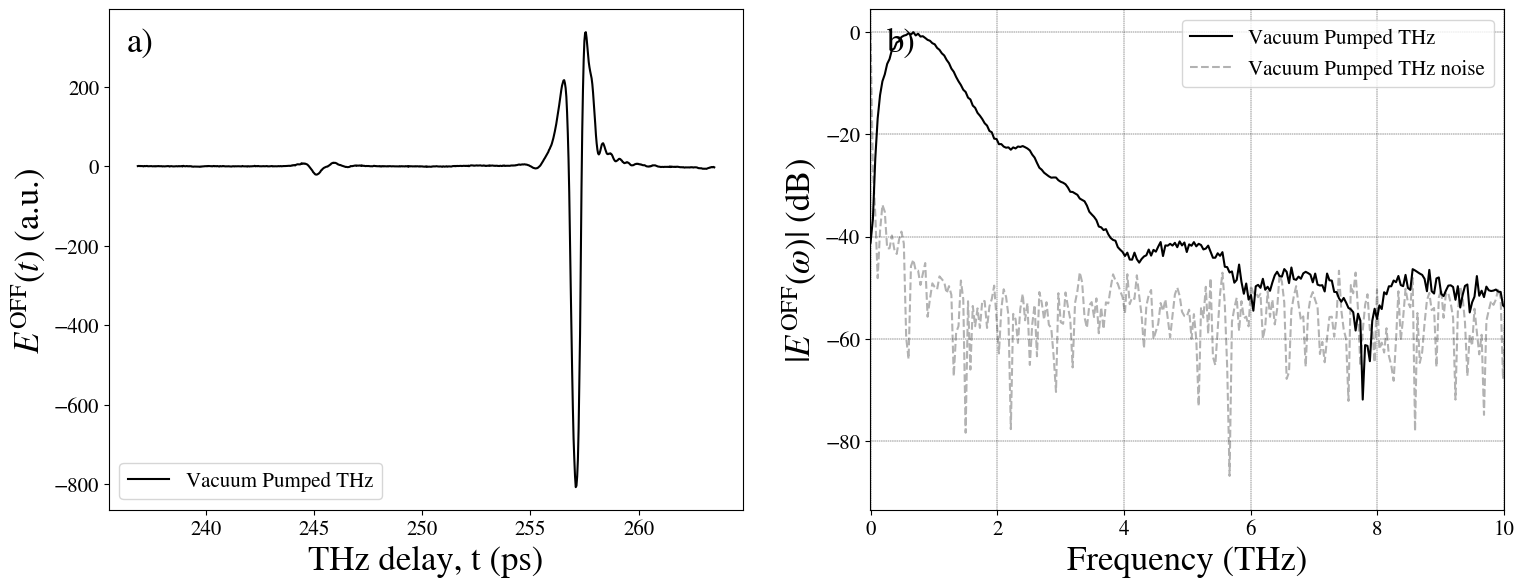

In [5]:
dataframe = generate_cleaned_up_dataframe("D:/Aldric/Anish's thin films/250930/1_ZnO_A_Dark THz.txt", limits=[0,800])
BW_lower_index, max_fft_E_off_index, BW_upper_index, bandwidth = extract_bandwidth(dataframe)
dark_spec_fig, dark_axs = plt.subplots(ncols=2,
                                        figsize=figure_size_2,
                                        gridspec_kw={'hspace': 0,
                                                    'wspace': 0.2})
dark_axs = plot_dark_spectrum(dark_axs,
                              dataframe,
                              label='Vacuum Pumped THz',
                              color='black',
                              legend=True)


In [ ]:
def get_transmission_function(ref_filename: str,
                              sample_filename: str,
                              window: list = [0,800],
                              window_type: str = "gaussian"):
    ref_data = generate_cleaned_up_dataframe(ref_filename, limits=window)
    sample_data = generate_cleaned_up_dataframe(sample_filename, limits=window)

    # Calculate the transmission function
    transmission_function = sample_data['fft_E_off'] / ref_data['fft_E_off']

    # Plot the transmission function
    plt.figure(figsize=(5, 5))
    plt.plot(ref_data['Frequencies (Hz)'][3:] * 1e-12,
             np.real(transmission_function[3:]),
             color='black',
             label='Transmission (Re)')
    plt.plot(ref_data['Frequencies (Hz)'][3:] * 1e-12,
             np.imag(transmission_function[3:]),
             color='red',
             label='Transmission (Im)')
    plt.xlim(bandwidth_xlim[0], 4)
    plt.ylim(-1.5, 1.5)
    plt.ylabel(r'$T(\omega)$ (a.u.)', fontsize=fontsize)
    plt.xlabel(r'Frequency (THz)', fontsize=fontsize)
    plt.legend(fontsize=tick_fontsize)
    plt.tight_layout()

    # return transmission_function

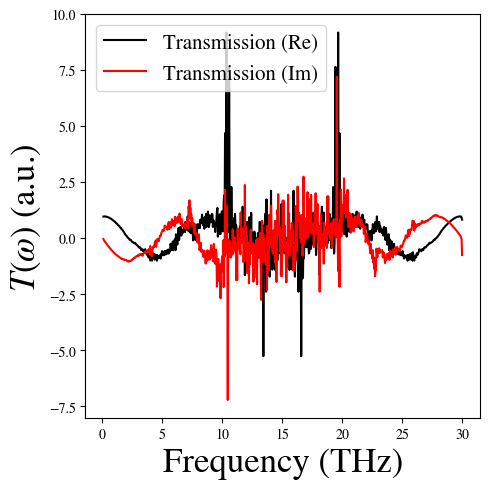

In [16]:
get_transmission_function("D:/Aldric/Anish's thin films/250930/1_reference_Dark THz.txt",
                          "D:/Aldric/Anish's thin films/250930/1_ZnO_A_Dark THz.txt")

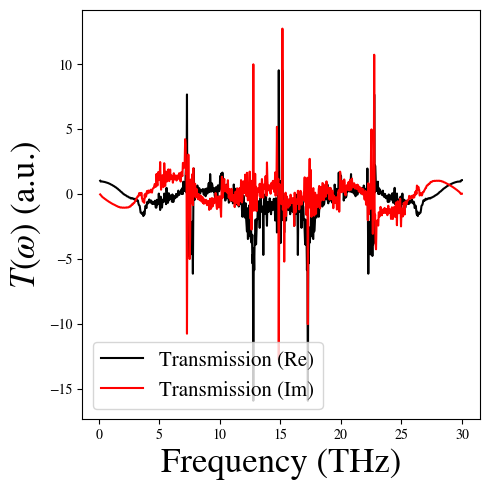

In [15]:
get_transmission_function("D:/Aldric/Anish's thin films/251009/1_reference_Dark THz.txt",
                          "D:/Aldric/Anish's thin films/251009/1_ZnO_B_Dark THz.txt")

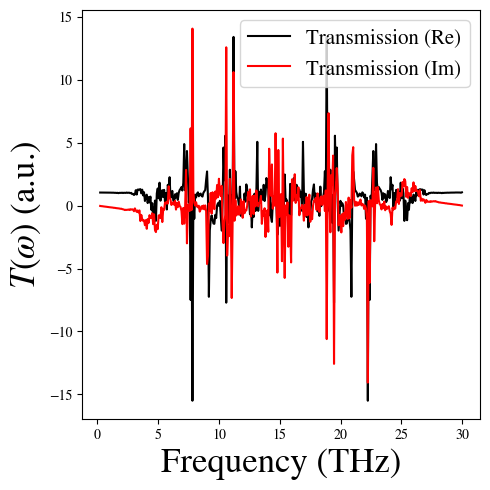

In [14]:
get_transmission_function("D:/Aldric/Data/251029/1_reference_Dark THz.txt",
                          "D:/Aldric/Data/251029/1_NW1129_30nm_Dark THz.txt")

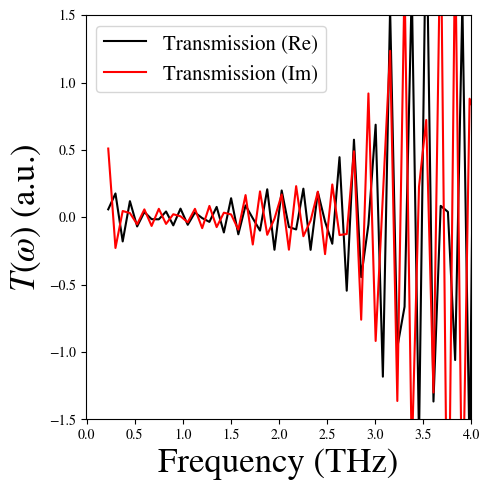

In [12]:
get_transmission_function("D:/Aldric/Data/251029/1_reference_Dark THz.txt",
                          "D:/Aldric/Data/251028/1_reference_Dark THz.txt")